# Building a K-Nearest Neighbours Classifier for Heart Disease Prediction

## Contents

* **[Introduction](#introduction)**

  - [k-NN Algorithm](#k-nn-algorithm)
  - [Dataset Acquisition](#dataset-acquisition)

    * [Data Dictionary](#data-dictionary)

--- 

* **[EDA and Visualisation](#eda-and-visualisation)**

  - [Visualising Numerical Columns](#visualising-numerical-columns)
  - [Visualising Categorical Columns](#visualising-categorical-columns)

    * [Grouping by Heart Disease](#grouping-by-heart-disease)

---

* **[Handling Missing Data](#handling-missing-data)**

---

* **[Train/Val/Test Split](#trainvaltest-split)**

---

* **[Data Preprocessing and Correlation Analysis](#data-preprocessing-and-correlation-analysis)**

  - [Scaling Numerical Features](#scaling-numerical-features)

---

* **[Model Fitting](#model-fitting)**

  - [One-feature Models](#one-feature-models)
  - [Multi-feature Classifier](#multi-feature-classifier)
  - [Model Optimisation](#optimizing-the-model-feature-selection)

---

* **[Model Evaluation](#evaluating-the-best-model-on-the-test-set)**

  - [Confusion Matrix](#confusion-matrix)

---

* **[Summary](#summary)**

  - [Future Work](#future-work)

## Introduction

An [article](https://www.who.int/news-room/fact-sheets/detail/cardiovascular-diseases-(cvds)) published by the World Health Organization (WHO) in July 2025 reports that cardiovascular diseases (CVDs) remain the leading cause of death globally. An estimated 19.8 million CVD related deaths occurred in 2022 (32% of the total global deaths for that year).

It is vital to note that most CVDs can be prevented by addressing behavioural and environmental risk factors (such as tobacco use, poor diet, obesity, air pollution, alcohol misuse and physical inactivity). Timely intervention by healthcare providers before CVDs are allowed to develop is therefore of paramount importance to allow patients an opportunity to change their lifestyle, potentially preventing the onset of life-threatening CVDs.

Consequently, there is clear interest in predictive modelling, assessing whether a patient is likely to be at risk of developing a CVD. To aid in diagnoses, we can leverage Machine Learning to build a model to classify patients, predicting if they are at risk of developing heart disease from a set of personal/health related features.

---
### k-NN Algorithm

One approach to this task is to implement the **k-Nearest Neighbours algorithm** (k-NN). This is a classification algorithm that predicts the class label of a datapoint from a set of features based on the most common class label of the $k^{th}$ nearest datapoints in the feature space to the datapoint to be classified.

+ This is a conceptually simple algorithm which can capture non-linearity in datasets and yield good results.

- However, k-NN algorithms are not particularly interpretable, which is a big downside in the medical field.

**A related project** on heart disease classification is available in the same repo where a logistic regression model is instead used. This can be considered an extension to this project which attempts to improve upon the model showcased here.

### Dataset Acquisition

A [publically available dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/code) has been collated from five anonymized hospitals on several patients. The dataset includes 11 potentially relevant features for heart disease prediction, alongside a binary target variable indicating if the patient does or does not have heart disease (1 or 0 respectively).

**Source:** fedesoriano (September 2021). Heart Failure Prediction Dataset. Retrieved [February 2026] from https://www.kaggle.com/fedesoriano/heart-failure-prediction.

#### Data Dictionary

| Column                      | Definition                                                                                                        |
|-----------------------------|-------------------------------------------------------------------------------------------------------------------|
| Age                         | Age of patient (years)                                                                                            |
| Sex                         | Biological gender of patient (M: male, F: female)                                                                 |
| ChestPainType               | Chest pain (TA: typical angina, ATA: atypical angina, NAP: non-anginal pain, ASY: asymptomatic)                   |
| RestingBP                   | Resting blood pressure (mm Hg)                                                                                    |
| Cholesterol                 | Serum cholesterol (mg/dL)                                                                                         |
| FastingBS                   | Fasting blood sugar (1: if FastingBS > 120 mg/dL (equiv. to 6.7 mmol/L), 0 otherwise)                             |
| RestingECG                  | Resting electrocardiogram results (Normal: Normal, ST: ST-T wave abnormality [T wave inversions and/or ST elevation/depression > 0.05 mV], LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria) |
| MaxHR                       | Maximum heart rate achieved during exercise test (bpm)                                                            |
| ExerciseAngina              | Exercise-induced angina (Y: Yes, N: No)                                                                          |
| Oldpeak                     | ST-segment depression (mm). Higher values indicate greater risk of myocardial ischemia and coronary heart disease |
| ST_Slope                    | The slope of the peak exercise ST segment (Up: upsloping, Flat: flat, Down: downsloping)                          |
| HeartDisease                | Target variable (1: Heart Disease, 0: Normal)                                                                     |



## EDA and Visualisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

dataset = pd.read_csv("heart_disease_prediction.csv")

dataset.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
dataset.shape

(918, 12)

The dataset contains 918 observations, 11 features and 1 target variable (`HeartDisease`).

In [3]:
dataset.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


From the above:

* The mean age of patients in the dataset is around 53 years.
* The median cholesterol value is roughly 25 mg/dl greater than the mean cholesterol value, indicating the distribution of cholesterol readings is left skewed (there may be outliers skewing the distribution).
* The `RestingBP` and `Cholesterol` columns have minima of 0 - this is not physically possible for a living patient, so will need to be addressed.

According to the [American Heart Association](https://www.heart.org/en/health-topics/cholesterol/about-cholesterol/what-your-cholesterol-levels-mean), a serum cholesterol measurement is a composite measure of high-density lipoprotein (HDL), low-density lipoprotein (LDL) plus 20% of the patient's triglyceride level. It is practically impossible for this to be measured as a value of zero.

In [4]:
dataset.describe(include="str")

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


A key takeaway looking at the categorical variables:

* Around 79% of the patients are biological males. There is a clear gender imbalance.

#### Raw Data - Missing Values

In [5]:
missing_values = dataset.isnull().sum()
missing_values

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

There are no missing values in the original state. However, we have uncovered the presence of `RestingBP` and `Cholesterol` values that are 0, which will need to be addressed prior to model development.

In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


### Visualising Numerical Columns

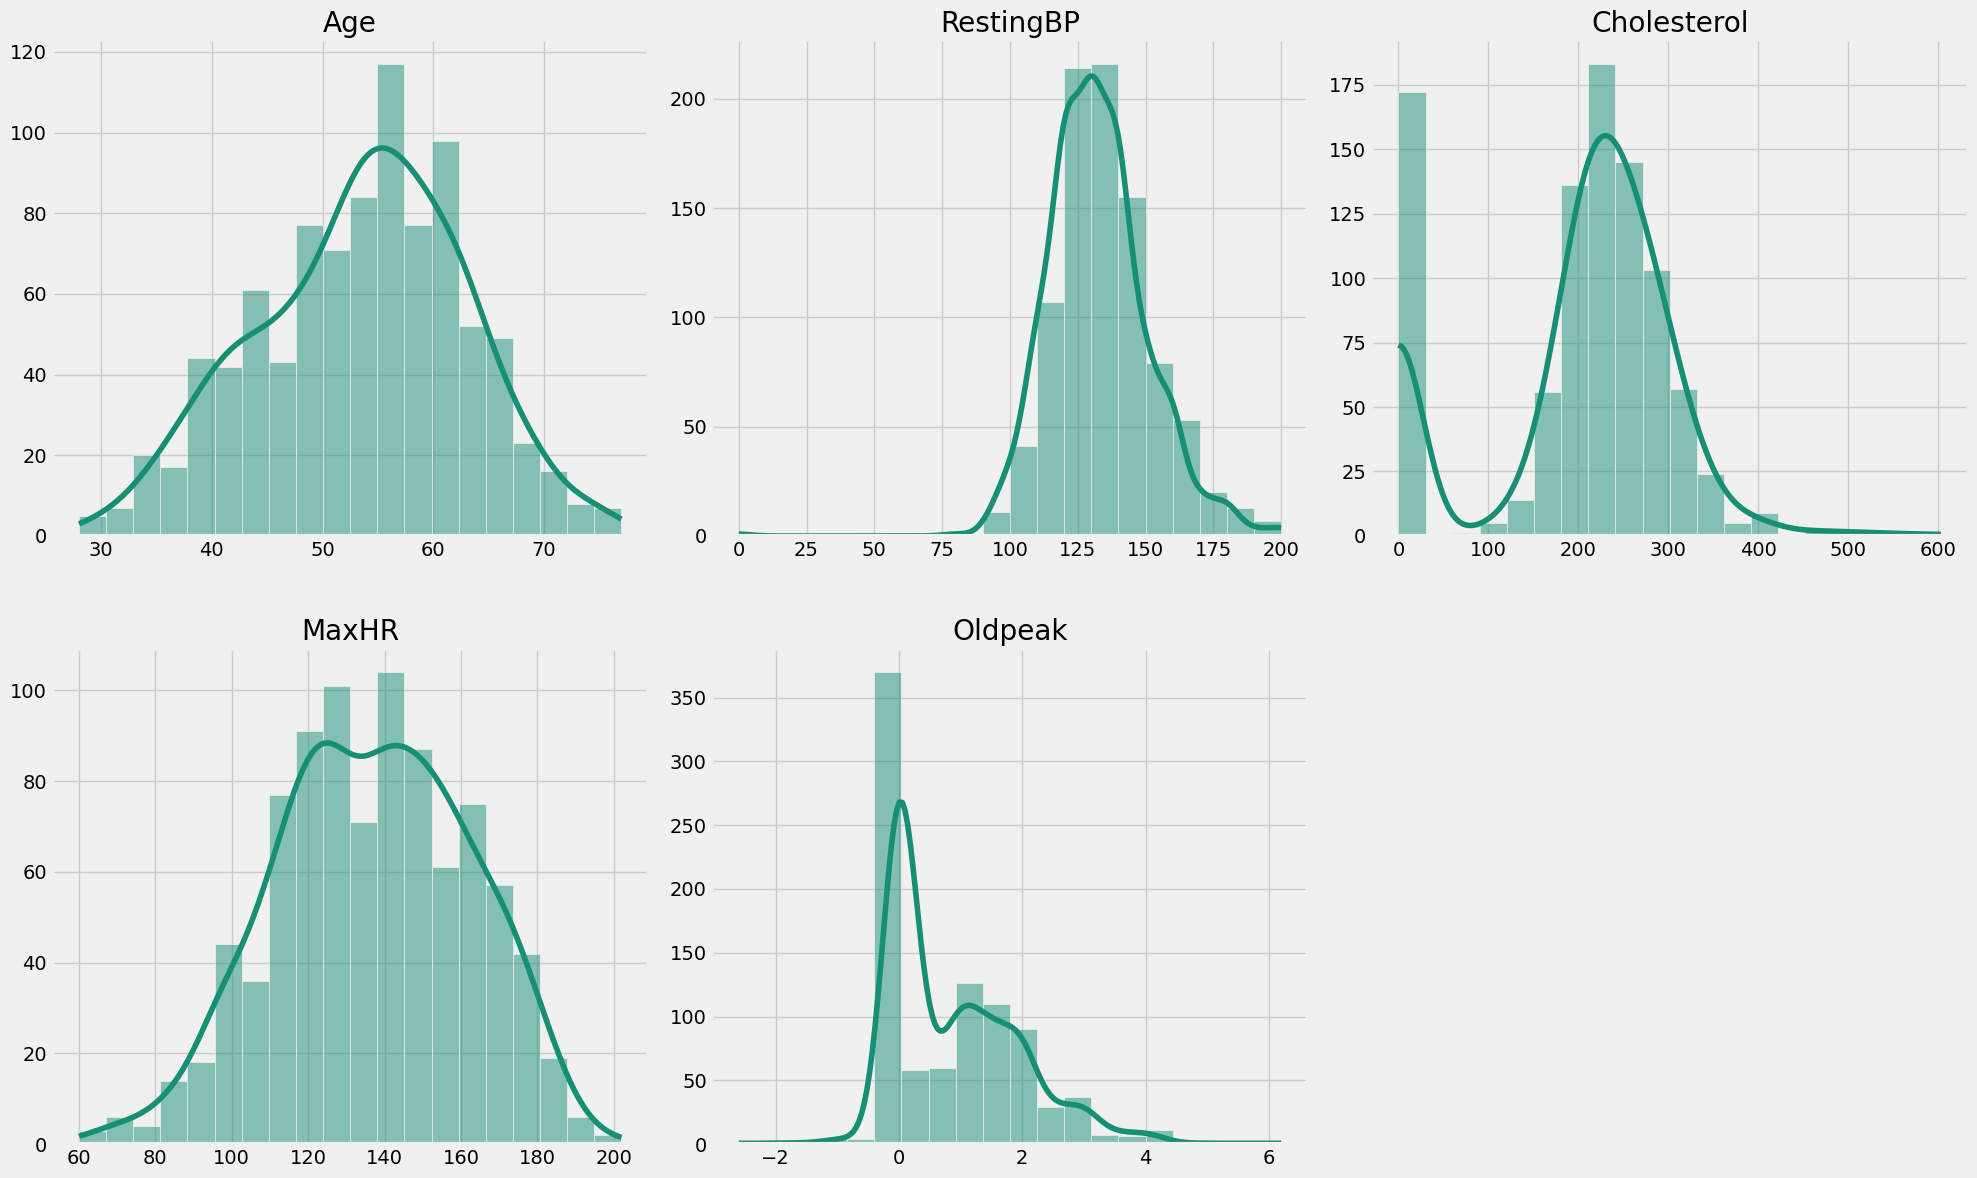

In [7]:
numerical_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

plt.figure(figsize=(20, 12))

for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(dataset[feature],
                 kde=True,
                 bins=20,
                 color="#178f75"
                 )
    plt.title(feature)
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout(h_pad=3)    
plt.show()

The distribution of the numeric variables are roughly normal, with some notable exceptions.

* The `Cholesterol` variable has a significant number of zero values, but it otherwise normally distributed. 

* `Oldpeak` is significantly right skewed, which is as expected from a clinical standpoint. There are however anomalous negative valued observations which is atypical - often measurement errors. These can be set to zero.

In [8]:
dataset[dataset["Oldpeak"] < 0]["Oldpeak"].value_counts()

Oldpeak
-0.1    2
-1.0    2
-0.5    2
-0.9    1
-2.6    1
-1.5    1
-1.1    1
-0.7    1
-0.8    1
-2.0    1
Name: count, dtype: int64

In [9]:
dataset["Oldpeak"] = dataset["Oldpeak"].apply(lambda x: 0 if x < 0 else x) # Replace negative values with 0
dataset[dataset["Oldpeak"] < 0].shape[0] # Check

0

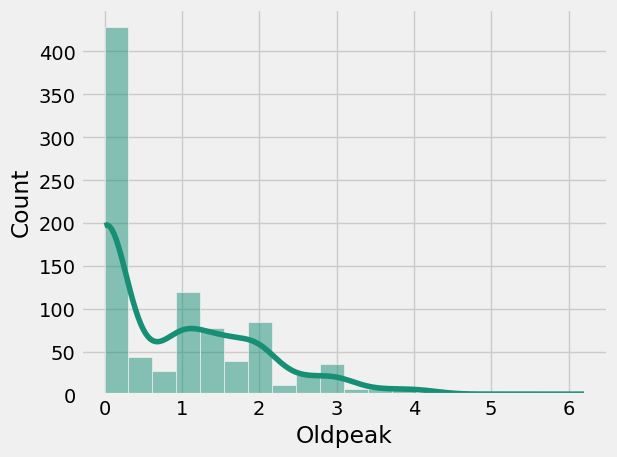

In [10]:
sns.histplot(dataset["Oldpeak"],
                 kde=True,
                 bins=20,
                 color="#178f75"
                 )

plt.tight_layout()
plt.show()

### Visualising Categorical Columns

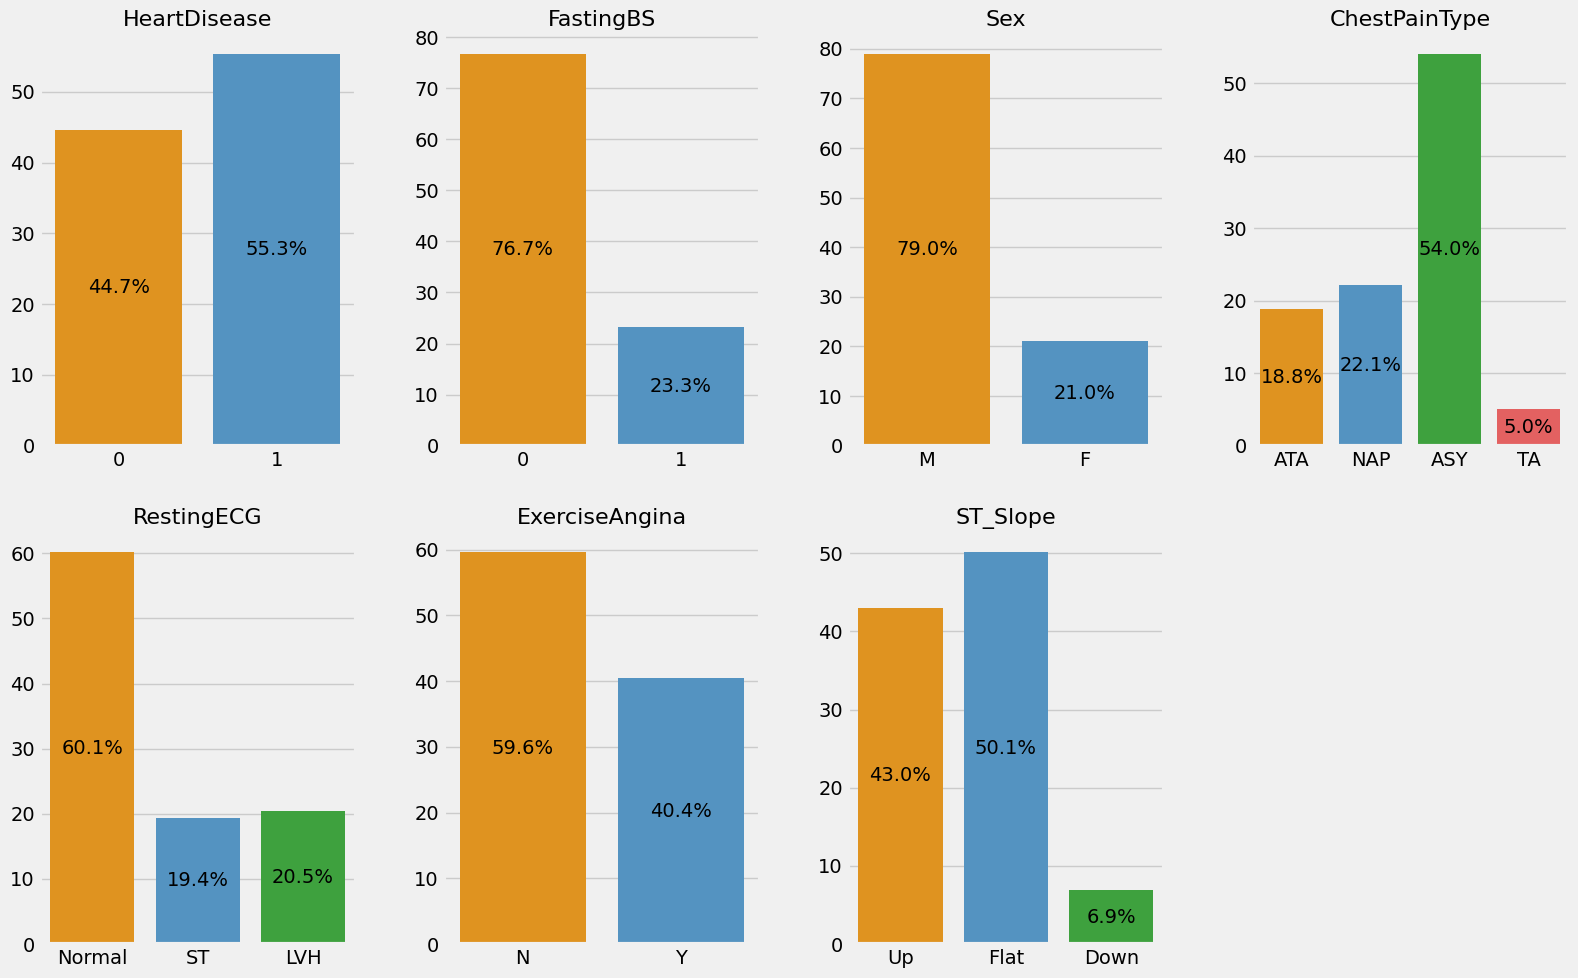

In [11]:
categorical_columns = ["HeartDisease", "FastingBS"]

for col in dataset.columns:
  if dataset.dtypes[col] == "str":
    categorical_columns.append(col)
    
plt.figure(figsize=(16, 10))

for col in categorical_columns:
  ax = plt.subplot(2, 4, categorical_columns.index(col) + 1)
  sns.countplot(x=col, 
                data=dataset,
                stat="percent", 
                palette=["#ff9900", "#4296d3", "#2eb12e", "#f84c4c"]
                )
  
  plt.title(col, fontsize=16)
  plt.ylabel("")
  plt.xlabel("")
  
  for container in ax.containers:
    ax.bar_label(container, label_type="center", fmt="%1.1f%%")
  
plt.tight_layout(h_pad=2.0, w_pad=3.0)
plt.show()

Key observations from the above:

* Roughly 55% of the observations are labelled with a positive result for `HeartDisease`. There is therefore, *slight* imbalance in the labels. A model could be slightly more biased towards classifying an unseen datapoint as having heart disease if there are more observations with heart disease during training.

* Roughly 30% of the observations have `RestingBS` values exceeding 120 mg/dl, which is a strong indicator of pre-diabetes or diabetes. 

* In approximately 54% of the observations, patients presented asymptomatic with regards to chest pain.

* The majority of patients (~60%) in the dataset have normal resting ECG traces.

* A sizeable percentage (~40%) of patients are diagnosed with exercise-induced angina.

Grouping the above counts by the `HeartDisease` variable will further uncover insights about the data distribution.

#### Grouping by Heart Disease

In [12]:
categorical_columns.remove("HeartDisease") # HeartDisease is the target variable, so remove from visualization

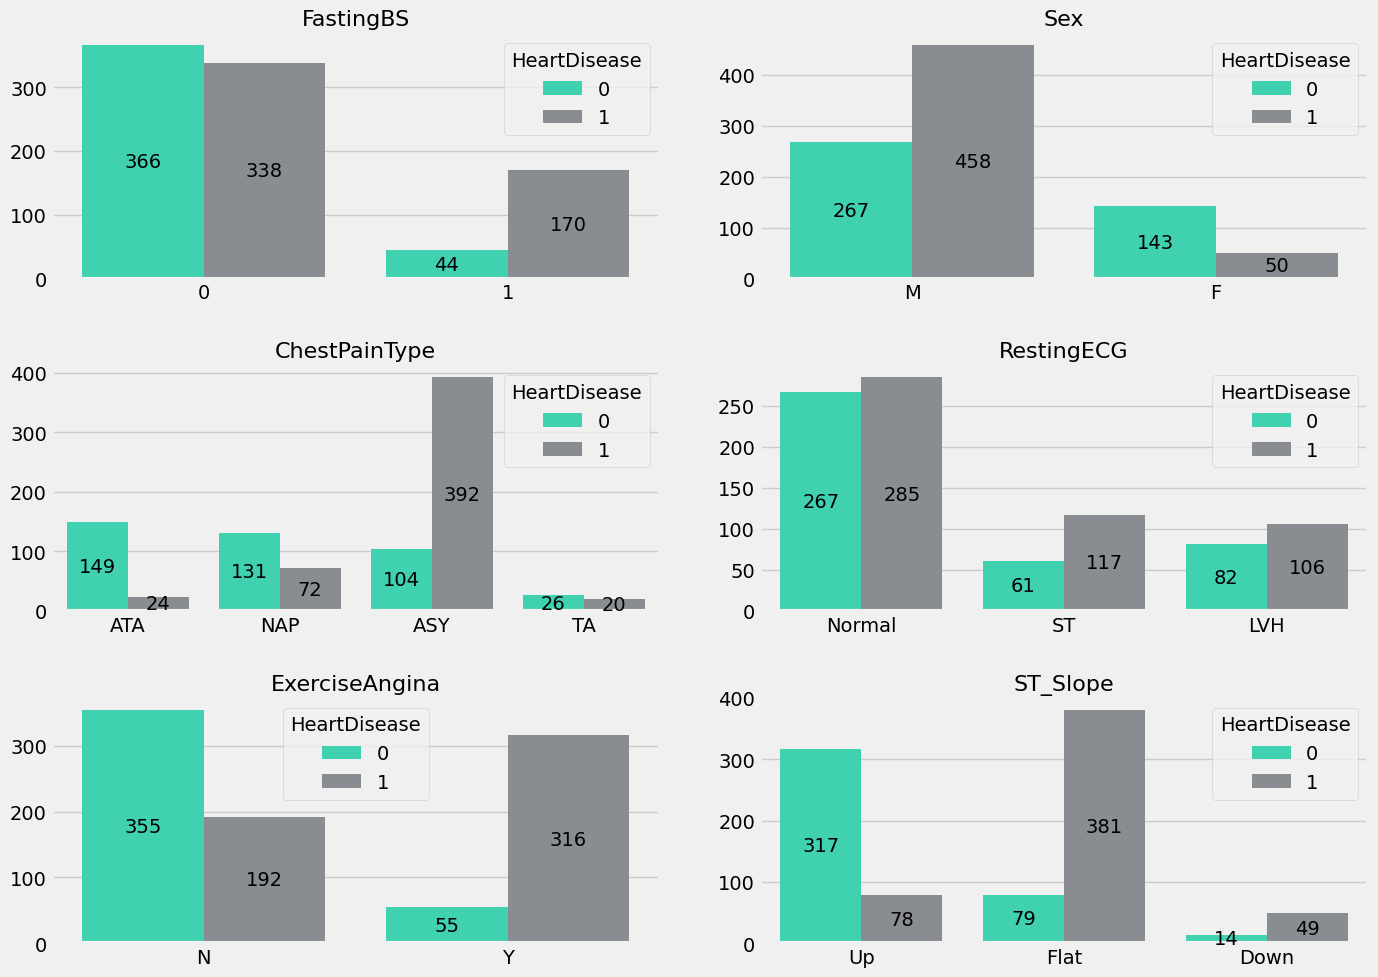

In [13]:
plt.figure(figsize=(14, 10))

for col in categorical_columns:
  ax = plt.subplot(3, 2, categorical_columns.index(col) + 1)
  sns.countplot(x=col, data=dataset, hue="HeartDisease", palette=["#28e9bf", "#888c92"])
  plt.title(col, fontsize=16)
  plt.ylabel("")
  plt.xlabel("")
  
  for container in ax.containers:
    ax.bar_label(container, label_type="center")
  
plt.tight_layout(h_pad=2.0, w_pad=3.0)
plt.show()

### Remarks

* It is even more apparent how skewed the dataset is towards male patients - only **50** of the 918 observations are females diagnosed with heart disease.

* A **significant** number of patients (392) diagnosed with heart disease have **asymptomatic chest pain**. This implies there are CVDs which do not have chest pain as a symptom.

* A large proportion of patients with blood sugar exceeding 120 mg/dL were diagnosed with heart disease compared to those who had resting blood sugars less than 120 mg/dL. This suggests pre-diabetic/diabetic patients are at a much greater risk of developing CVDs.

* Around 85% of the patients diagnosed with exercise-induced angina were diagnosed with heart disease.

* Of all patients with a flat ST slope, around 83% were diagnosed with heart disease. This suggests a flat ST slope is a fairly reliable indicator of heart disease.

---

## Handling Missing Data

In [14]:
dataset[dataset["RestingBP"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


Since there is only one observation with a zero in the `RestingBP` field, we can drop this row.

In [15]:
dataset.drop(dataset[dataset["RestingBP"] == 0].index, inplace=True)
dataset[dataset["RestingBP"] == 0].shape[0] # check if dropped

0

In [16]:
dataset[dataset["Cholesterol"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


There are 171 observations with a recorded value of 0 for `Cholesterol`. This is a sizeable proportion of the full dataset, so it is best to impute the missing data rather than dropping it.

## Train/Val/Test Split

Before this can be done, the dataset must be split to prevent data leakage (test data influencing training data). Due to the moderate size of the dataset (~900 observations) a 70/15/15 Train/Validation/Test split will be implemented. It is important that the majority of the observations are reserved for training, leaving the remaining 30% of observations for accuracy evaluation during the fine-tuning and final evaluation stages of the workflow.

The test set will only be exposed to the model during final evaluation of the fine-tuned model to ensure there is no bias.

In [17]:
from sklearn.model_selection import train_test_split

X = dataset.drop("HeartDisease", axis=1)
y = dataset["HeartDisease"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15*X.shape[0]/X_train.shape[0], stratify=y_train, random_state=42)

print(f"""
X_train Rows: {X_train.shape[0]}
X_val Rows: {X_val.shape[0]} 
X_test Rows: {X_test.shape[0]} 

Train Distribution: 
{y_train.value_counts()}

Validation Distribution: 
{y_val.value_counts()}

Test Distribution: 
{y_test.value_counts()}
""")


X_train Rows: 641
X_val Rows: 138 
X_test Rows: 138 

Train Distribution: 
HeartDisease
1    355
0    286
Name: count, dtype: int64

Validation Distribution: 
HeartDisease
1    76
0    62
Name: count, dtype: int64

Test Distribution: 
HeartDisease
1    76
0    62
Name: count, dtype: int64



### Imputing Missing Cholesterol Values

One approach to provide relatively accurate imputed values in place of missing cholesterol readings is to take the median cholesterol value of the training set when grouping the data by `Sex` and `RestingECG` of the patient. The impute value should be computed from training data alone to prevent data leakage.

>Consider the scenario where we have a female patient with a normal ECG trace, but do not have their cholesterol reading: 
>
>It is likely to be a more accurate approach to impute this missing value with the median of the cholesterol readings of all other females with normal ECG traces, rather than simply imputing by the median cholesterol value across the entire training dataset.

Below, a pivot table is created to find the relevant imputation values.

In [18]:
non_zero_cholesterol = X_train[X_train["Cholesterol"] != 0]

In [19]:
pivot_table = pd.pivot_table(non_zero_cholesterol, values="Cholesterol", index=["Sex"], columns="RestingECG", aggfunc="median")
pivot_table

RestingECG,LVH,Normal,ST
Sex,,,
F,268.0,239.5,243.5
M,246.0,235.0,230.5


If we attempt to make the imputation more complex by also grouping by the `Age` feature, it highlights some limitations of the dataset:

In [20]:
pivot_table_with_age = pd.pivot_table(non_zero_cholesterol, values="Cholesterol", index=["Age", "Sex"], columns="RestingECG", aggfunc="median")
pivot_table_with_age

,RestingECG,LVH,Normal,ST
Age,Sex,,,
29,M,204.0,263.0,NaN
30,F,NaN,NaN,237.0
31,M,NaN,270.0,NaN
32,M,NaN,254.0,NaN
33,F,NaN,246.0,NaN
...,...,...,...,...
74,M,NaN,216.0,258.0
75,M,NaN,310.0,203.0
76,F,NaN,NaN,197.0


Since the dataset is relatively small, there are an **insufficient number of datapoints** to find accurate median values for every single category of patient. For example, there are no 30 year old females with a normal resting ECG trace in the dataset, hence there is no imputable cholesterol value for a patient that does meet this criteria.

As a result, we will use the median values calculated in the first pivot table above to impute missing cholesterol values.

In [21]:
def impute_missing_cholesterol(row):
  sex = row["Sex"]
  ecg = row["RestingECG"]
  cholesterol = row["Cholesterol"]
  
  if cholesterol != 0:
    return row
  else:
    for index in pivot_table.index:
      for column in pivot_table.columns:
        if (index == sex) and (column == ecg):
          row["Cholesterol"] = pivot_table.loc[index, column]
    return row

In [22]:
X_train = X_train.apply(impute_missing_cholesterol, axis=1)
X_train["Cholesterol"].value_counts()

Cholesterol
235.0    71
230.5    35
246.0    14
254.0    10
223.0     9
         ..
385.0     1
85.0      1
286.0     1
329.0     1
180.0     1
Name: count, Length: 197, dtype: int64

In [23]:
X_train[X_train["Cholesterol"] == 0].shape[0]

0

In [24]:
X_train[["RestingBP", "Cholesterol"]].describe()

,RestingBP,Cholesterol
count,641.000000,641.000000
mean,132.684867,244.091264
std,18.270979,53.750943
min,80.000000,85.000000
25%,120.000000,216.000000
50%,130.000000,235.000000
75%,140.000000,269.000000
max,200.000000,603.000000


We have successfully addressed the zero values in the `RestingBP` and `Cholesterol` fields. We can now impute the val and test sets with the training impute value:

In [25]:
X_val = X_val.apply(impute_missing_cholesterol, axis=1)
X_test = X_test.apply(impute_missing_cholesterol, axis=1)

print(f"""
X_val:
{X_val["Cholesterol"].value_counts()}
Number of zeros: {X_val[X_val["Cholesterol"] == 0].shape[0]}

X_test:
{X_test["Cholesterol"].value_counts()}
Number of zeros: {X_test[X_test["Cholesterol"] == 0].shape[0]}
""")


X_val:
Cholesterol
235.0    20
230.5    11
260.0     3
243.0     3
196.0     3
         ..
277.0     1
355.0     1
292.0     1
258.0     1
339.0     1
Name: count, Length: 80, dtype: int64
Number of zeros: 0

X_test:
Cholesterol
235.0    11
230.5     5
246.0     4
218.0     3
239.5     3
         ..
289.0     1
220.0     1
179.0     1
277.0     1
163.0     1
Name: count, Length: 94, dtype: int64
Number of zeros: 0



To get an idea of the effect of the imputation on the cholesterol distribution, we can plot a histograms of each dataset:

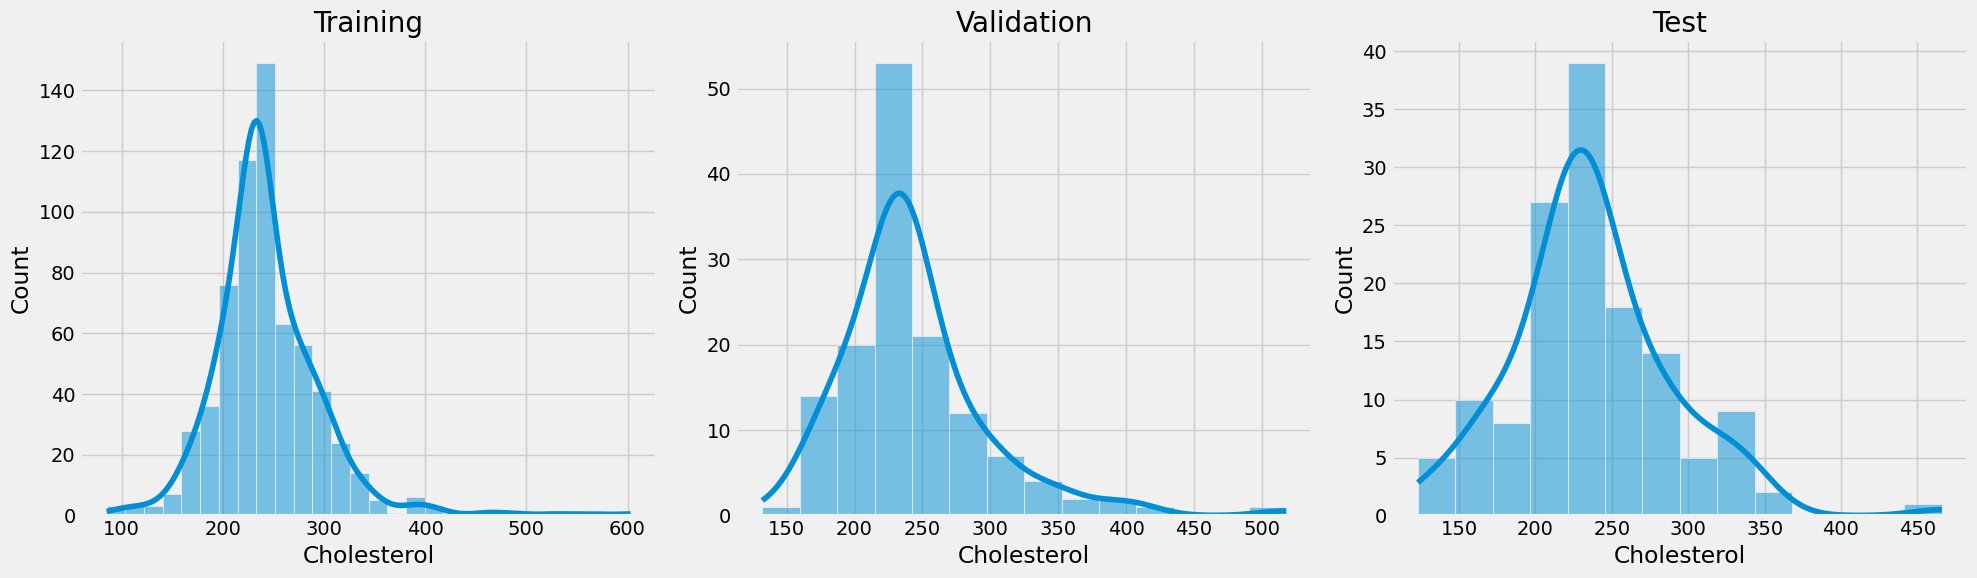

In [26]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.title("Training")
sns.histplot(X_train["Cholesterol"], kde=True, bins=28)

plt.subplot(1, 3, 2)
plt.title("Validation")
sns.histplot(X_val["Cholesterol"], kde=True, bins=14)

plt.subplot(1, 3, 3)
plt.title("Test")
sns.histplot(X_test["Cholesterol"], kde=True, bins=14)

plt.tight_layout()
plt.show()

Imputation has successfully handled the missing cholesterol values. This has the effect of artificially centralising the distribtutions and reducing the skewness of the data, which is beneficial. Correlations between cholesterol and other features are likely to be diluted by this, which will be considered in the subsequent EDA.

## Data Preprocessing and Correlation Analysis

In preparation for model training, categorical variables need to be **one-hot encoded** to be interpretable. The pandas `get_dummies()` function can transforms categorical columns into dummy variables to achieve this.

In [27]:
X_train = pd.get_dummies(X_train, drop_first=True)

X_train.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
258,51,150,200.0,0,120,0.5,False,False,True,False,True,False,False,False,True
564,57,144,270.0,1,160,2.0,True,False,False,False,False,True,True,True,False
296,50,145,235.0,1,139,0.7,True,False,False,False,True,False,True,True,False
844,52,118,186.0,0,190,0.0,True,False,False,True,False,False,False,True,False
593,64,130,258.0,1,130,0.0,True,False,False,False,False,False,False,True,False


In [28]:
# one-hot encode the categorical columns for the validation and test sets
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

To inform feature selection, the Pearson correlation coefficient between each independent varible (feature) in the dataset can be found. By taking the square of Pearson's r, the coefficient of determination $R^{2}$ can be found, acting as a measure for the strength of the linear correlation between the variables.

*Note,* squaring Pearson's r is sensible in this case since we are not concerned with the direction of the correlation. Squaring the value will also mean more weight is assigned to stronger correlations, emphasising which features are likely to be more important for prediction of heart disease.

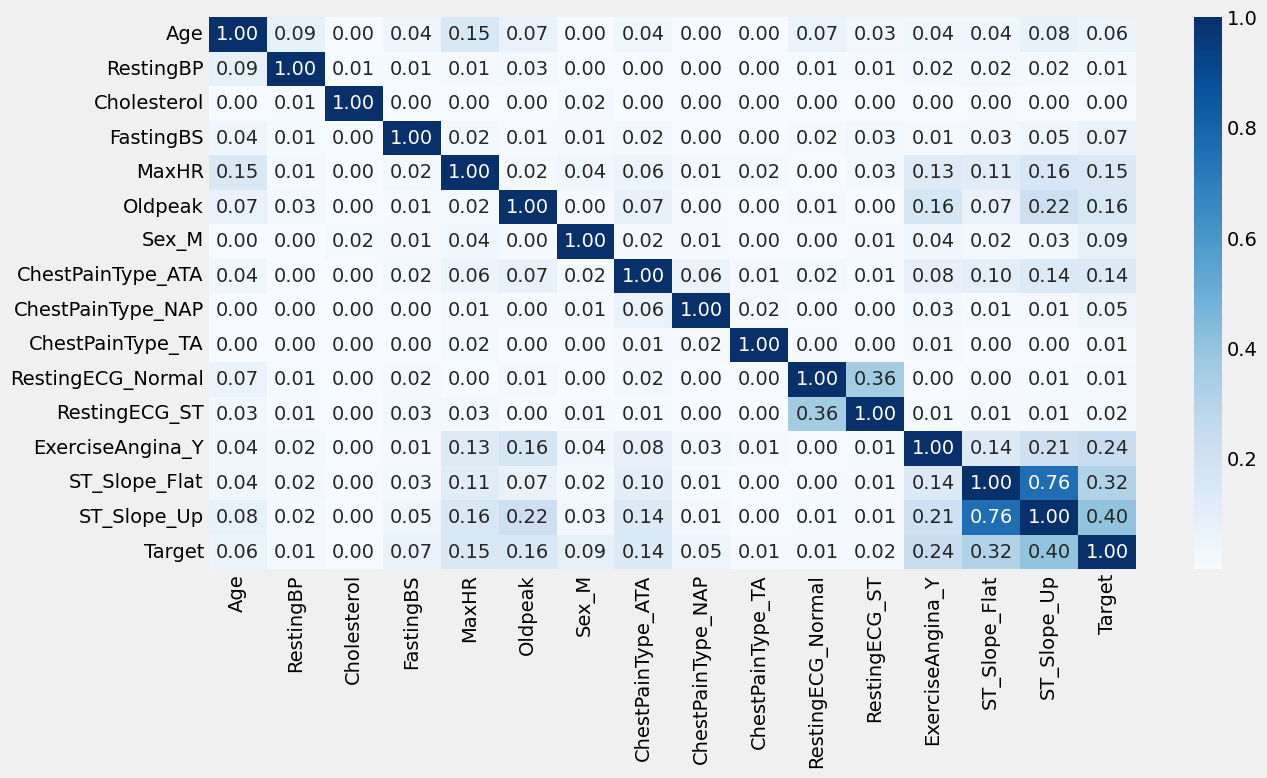

In [29]:
X_train["Target"] = y_train # temporarily add the target column to the training set for correlation analysis
correlations = (X_train.corr())**2 # find the square of the pearson correlation coefficient - i.e., the coefficient of determination R^2

plt.figure(figsize=(14, 8))
corrs = sns.heatmap(correlations, annot=True, fmt=".2f", cmap="Blues")

plt.tight_layout()
plt.show()

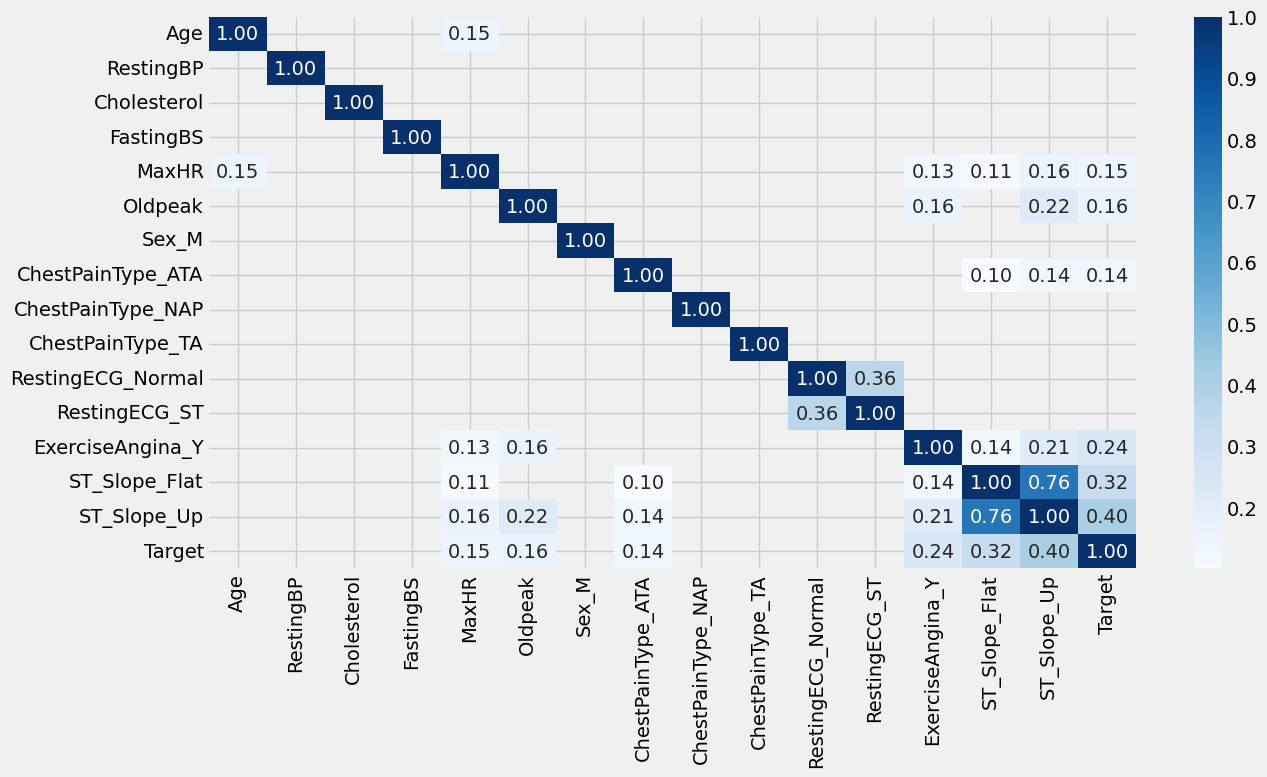

In [30]:
plt.figure(figsize=(14, 8))
sns.heatmap(correlations[correlations > 0.1], annot=True, fmt=".2f", cmap="Blues") # filter to show the stronger correlations

plt.tight_layout()
plt.show()

### Potential Collinearity

There is evidence of collinearity in the feature space due to cross-feature correlations. Despite this, it is not a huge concern when implementing the k-NN algorithm since it is not particularly interpretable. Due to this, we can aim to implement the model with the goal of maximizing accuracy.

In [31]:
correlations["Target"].sort_values(ascending=False)

Target               1.000000
ST_Slope_Up          0.404292
ST_Slope_Flat        0.315350
ExerciseAngina_Y     0.243686
Oldpeak              0.157849
MaxHR                0.147067
ChestPainType_ATA    0.137284
Sex_M                0.087455
FastingBS            0.072019
Age                  0.062040
ChestPainType_NAP    0.052132
RestingECG_ST        0.016017
RestingBP            0.013942
RestingECG_Normal    0.013831
ChestPainType_TA     0.006665
Cholesterol          0.000072
Name: Target, dtype: float64

In [32]:
X_train = X_train.drop(columns=["Target"]) # remove the target column

### Relevant Features

The features that are seemingly the most significant include:

* ST_Slope
* ExerciseAngina
* Oldpeak
* ChestPainType
* MaxHR
* Sex
* Age
* FastingBS

Although `FastingBS`, `Age` and `Sex` are more weakly correlated (all $R^{2}$ values less than 0.1), visualization of the data and domain knowledge suggest these variables may still be relevant. It is also important to remember that the Pearson correlation coefficient is a simple linear bivariate analysis, so will not capture more complex relationships and interactions between other variables. 

Medical evidence suggests age, gender and long term elevated blood sugar levels are strongly associated to the onset of heart disease, so these features will also be included in the model.

Sources:
* [Cardiac aging and heart disease in humans](https://link.springer.com/article/10.1007/s12551-017-0255-9) 
* [Risk factors for coronary heart disease: implications of gender](https://academic.oup.com/cardiovascres/article-abstract/53/3/538/324835)
* [The Whitehall Study: CORONARY-HEART-DISEASE RISK AND IMPAIRED GLUCOSE TOLERANCE](https://www.sciencedirect.com/science/article/abs/pii/S0140673680926513)

>Note, feature selection will be conducted during model training, this correlation analysis is simply to help inform which features are likely to be good candidates. 

---

Interestingly, `Cholesterol` has a weak linear correlation with `HeartDisease`, so we can try building the model without this feature. This is likely because the `Cholesterol` feature measures total serum cholesterol, a composite measure of HDL, LDL and triglycerides in the blood. 

According to the [UK National Health Service (NHS)](https://www.nhs.uk/conditions/high-cholesterol/cholesterol-levels/) and [Cleveland Clinic](https://my.clevelandclinic.org/health/articles/24391-ldl-cholesterol), it is primarily **Low-Density Lipoprotein (LDL)** that increases the risk of heart disease and stroke, whilst **High-Density Lipoprotein (HDL)** is associated with *lowering* the risk of heart disease and stroke. 

Since we cannot isolate the contrasting effects of HDL and LDL levels from the existing dataset, we cannot investigate this further. Additional data collection would be of great benefit for future versions of the model.

### Scaling Numerical Features

Before moving to model fitting, it is necessary to scale the numerical features. This is non-negotiable for a k-NN model as the algorithm is highly sensitive to feature scale. 

With the exception of `Oldpeak`, numerical features are to be standardised using z-score normalisation. This transformation will only be fitted on the training set and subsequently applied to the test set to ensure consistency and prevent information leakage.

Since the `Oldpeak` distribution is highly right skewed, it can instead be scaled using the `RobustScaler` which uses the median and IQR to scale the data, which will prevent the scaling from being distorted.

In [33]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler = StandardScaler()
oldpeak_scaler = RobustScaler()

X_train[["Age", "RestingBP", "Cholesterol", "MaxHR"]] = scaler.fit_transform(X_train[["Age", "RestingBP", "Cholesterol", "MaxHR"]])
X_train["Oldpeak"] = oldpeak_scaler.fit_transform(X_train[["Oldpeak"]])

X_val[["Age", "RestingBP", "Cholesterol", "MaxHR"]] = scaler.transform(X_val[["Age", "RestingBP", "Cholesterol", "MaxHR"]])
X_val["Oldpeak"] = oldpeak_scaler.transform(X_val[["Oldpeak"]])

X_test[["Age", "RestingBP", "Cholesterol", "MaxHR"]] = scaler.transform(X_test[["Age", "RestingBP", "Cholesterol", "MaxHR"]])
X_test["Oldpeak"] = oldpeak_scaler.transform(X_test[["Oldpeak"]])

X_train.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
258,-0.250883,0.948425,-0.820929,0,-0.635464,0.000000,False,False,True,False,True,False,False,False,True
564,0.374859,0.619779,0.482391,1,0.896869,1.000000,True,False,False,False,False,True,True,True,False
296,-0.355173,0.674553,-0.169269,1,0.092394,0.133333,True,False,False,False,True,False,True,True,False
844,-0.146592,-0.804354,-1.081593,0,2.046118,-0.333333,True,False,False,True,False,False,False,True,False
593,1.104892,-0.147062,0.258965,1,-0.252381,-0.333333,True,False,False,False,False,False,False,True,False


#### Verifying Scaled Distributions

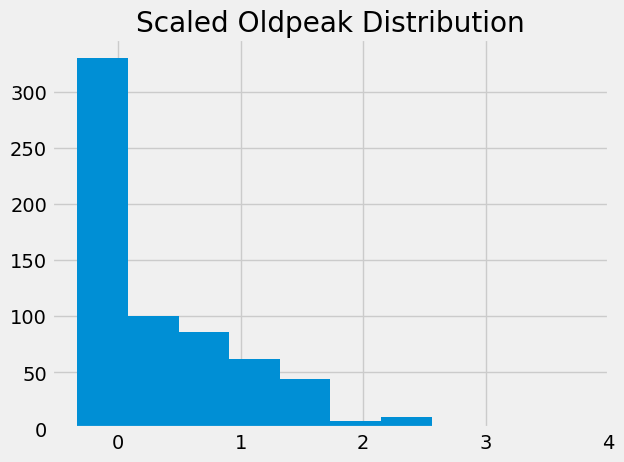

In [34]:
X_train["Oldpeak"].plot.hist(legend=False)
plt.title("Scaled Oldpeak Distribution")
plt.ylabel("")

plt.show()

This is an improvement over the raw oldpeak data. Although skew still remains, the data is centered around 0 and the spread is more balanced around the median, reducing the influence of extreme values. It is also slightly better than what a standard scaler would provide as the standard scaler uses mean and standard deviation, which are more sensitive to extrema.

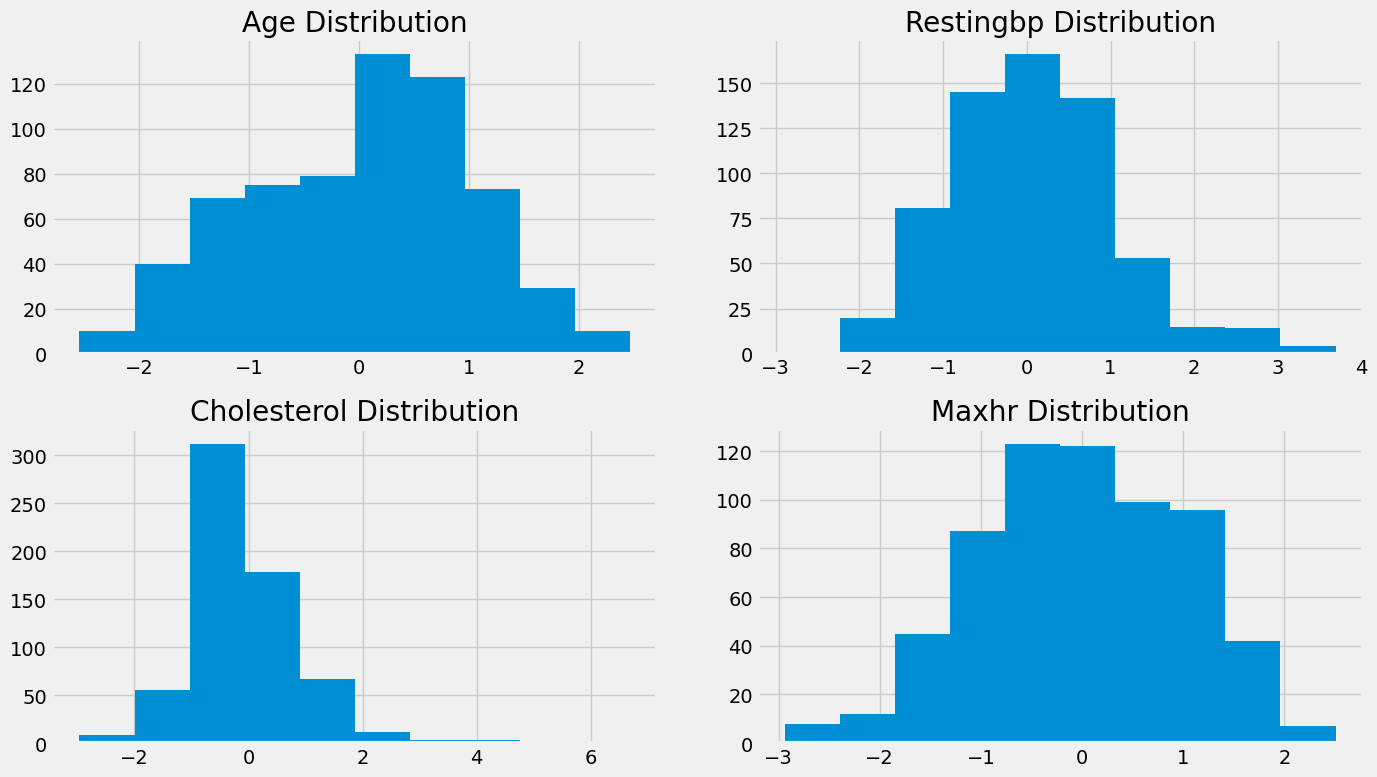

In [35]:
standard_train = X_train[["Age", "RestingBP", "Cholesterol", "MaxHR"]]

plt.figure(figsize=(14, 8))

for col in standard_train.columns:
  plt.subplot(2, 2, standard_train.columns.get_loc(col)+1)
  standard_train[col].plot.hist()
  plt.title(f"{col.title()} Distribution")
  plt.ylabel("")

plt.tight_layout(w_pad=3)
plt.show()

## Model Fitting

Initial model screening with a range of different feature spaces will be conducted to optimize model performance to decide upon the optimal feature set. Hyperparameters will also be tuned using a cross-validated grid search.

In [36]:
y_train.value_counts(normalize=True)

HeartDisease
1    0.553822
0    0.446178
Name: proportion, dtype: float64

In [37]:
X_train["Sex_M"].value_counts(normalize=True)

Sex_M
True     0.794072
False    0.205928
Name: proportion, dtype: float64

There is however a considerable imbalance in the biological sex of patients in the training set, which may mean the model becomes poorer at predicting heart disease for female patients. 

### One-feature Models

In [38]:
from sklearn.neighbors import KNeighborsClassifier

k = 5

knn = KNeighborsClassifier(n_neighbors=k)

for feature in X_train.columns:
  knn.fit(X_train[[feature]], y_train)

  train_score = knn.score(X_train[[feature]], y_train)*100
  val_score = knn.score(X_val[[feature]], y_val)*100

  print(f"""A one-feature k-NN classifier trained on '{feature}' using k={k}:
Training Accuracy: {train_score:.3f}%
Model Validation Accuracy: {val_score:.3f}%
------------------------------------------------------------------------""")

A one-feature k-NN classifier trained on 'Age' using k=5:
Training Accuracy: 55.538%
Model Validation Accuracy: 61.594%
------------------------------------------------------------------------
A one-feature k-NN classifier trained on 'RestingBP' using k=5:
Training Accuracy: 59.750%
Model Validation Accuracy: 53.623%
------------------------------------------------------------------------
A one-feature k-NN classifier trained on 'Cholesterol' using k=5:
Training Accuracy: 72.387%
Model Validation Accuracy: 55.797%
------------------------------------------------------------------------
A one-feature k-NN classifier trained on 'FastingBS' using k=5:
Training Accuracy: 55.382%
Model Validation Accuracy: 55.072%
------------------------------------------------------------------------
A one-feature k-NN classifier trained on 'MaxHR' using k=5:
Training Accuracy: 66.615%
Model Validation Accuracy: 62.319%
------------------------------------------------------------------------
A one-feature

The best performing one-feature model with $k=5$ used the `ST_Slope` feature, with a training accuracy of ~82.1% and validation accuracy of ~76.1%. 

This is expected based on the prior EDA analysis since it was revealed that the majority of patients with an upwards sloping ST segment were not diagnosed with heart disease (~80%). Of those that did not have an upwards sloping ST segment, 82% were diagnosed with heart disease, meaning this feature seems to be a good predictor for heart disease.

### Multi-feature Classifier

In [39]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

train_score = knn.score(X_train, y_train)*100
val_score = knn.score(X_val, y_val)*100

print(f"""
Initial Model Training Accuracy: {train_score:.3f}%
Initial Model Validation Accuracy: {val_score:.3f}%""")


Initial Model Training Accuracy: 87.832%
Initial Model Validation Accuracy: 86.957%


Using the entire feature space, the training accuracy and validation accuracy has considerably improved.

A training accuracy of ~87.8% suggests the model is fitting the training data far more closely than the best one-feature classifier with $k=5$. The improved validation accuracy compared to the one-feature classifier indicates the model is also performing better when classifying unseen observations. 

The training and validation accuracy values are also highly comparable, implying the model is not over or underfitting.

### Model Optimisation

To reduce dimensionality and improve distance-based separation, feature selection can be performed using a univariate statistical approach (`SelectKBest`). The optimal number of features can be treated as a hyperparameter and determined through cross-validation within the training set only.

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipe = Pipeline([
    ("select", SelectKBest()),
    ("knn", KNeighborsClassifier())
])

grid_params = {
    "select__k": [3, 5, 7, 9, 10, 11],
    "knn__n_neighbors": [3, 5, 7, 9, 11, 12, 13, 14, 15, 16, 17, 18],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(estimator=pipe, 
                    param_grid=grid_params,
                    cv=cv,
                    scoring="roc_auc",
                    verbose=1, 
                    n_jobs=-1
                    )

grid.fit(X_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance'], 'select__k': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.-

In [41]:
print(grid.best_params_)

{'knn__metric': 'manhattan', 'knn__n_neighbors': 17, 'knn__weights': 'uniform', 'select__k': 10}


Optimised model:

* 10 total predictors

* $k=17$

* Manhattan Distance Metric

* Uniform weights (unweighted)

In [42]:
print(f"Best model ROC-AUC score: {grid.best_score_}")

Best model ROC-AUC score: 0.9209422901595904


The cross-validated training ROC-AUC (Area Under the Receiver Operator Characteristic Curve) score for this classifier is strong, nearing a perfect score of 1. This suggests the model is able to discriminate between the two class labels effectively.

In [43]:
knn_model = grid.best_estimator_

In [44]:
chosen_features = X_train.columns[knn_model.named_steps["select"].get_support()]
chosen_features

Index(['Age', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ExerciseAngina_Y', 'ST_Slope_Flat',
       'ST_Slope_Up'],
      dtype='str')

Optimising with `SelectKBest` reduced the feature space to include:

* Age

* Sex

* ChestPainType

* ExerciseAngina

* FastingBS

* MaxHR

* Oldpeak

* ST_Slope

Notably, `Cholesterol`, `RestingBP` and `RestECG` were eliminated from the model.

In [45]:
print(f"Accuracy of best model: {knn_model.score(X_train, y_train)}")

Accuracy of best model: 0.8658346333853354


A cross-validated training accuracy of 86.6% is strong.

## Evaluating the Best Model on the Test Set

Since cross-validation was used to tune the best model, we can combine the validation set into the test set for a final evaluation on a larger set of data.

In [46]:
X_test = pd.concat([X_val, X_test], axis=0)
y_test = pd.concat([y_val, y_test], axis=0)

In [47]:
print(f"""
Test Rows: {X_test.shape[0]}

Test Distribution:
{y_test.value_counts()}
""")


Test Rows: 276

Test Distribution:
HeartDisease
1    152
0    124
Name: count, dtype: int64



In [48]:
knn_model.score(X_test, y_test)

0.8731884057971014

A testing accuracy of 87.3% is very strong, and comparable to the cross-validated training accuracy (86.6%). The model is seemingly not overfitting or underfitting, meaning it generalises well to unseen data.

The strong performance may reflect effective preprocessing and feature selection, though results could be influenced by split variability.

### Confusion Matrix

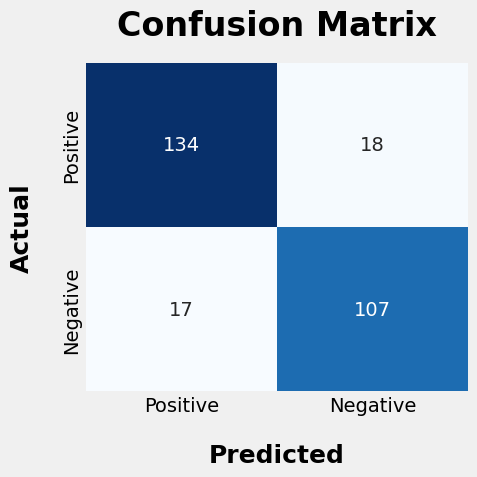

In [49]:
from sklearn.metrics import confusion_matrix, fbeta_score, roc_auc_score

predictions = knn_model.predict(X_test)

matrix = confusion_matrix(y_test, predictions, labels=[1, 0])

plt.figure(figsize=(5, 5))
sns.heatmap(matrix, annot=True, cbar=False, xticklabels=["Positive", "Negative"], fmt="d", yticklabels=["Positive", "Negative"], cmap="Blues")
plt.title("Confusion Matrix", pad=20, weight="bold", size=24)
plt.xlabel("Predicted", size=18, weight="bold", labelpad=20)
plt.ylabel("Actual", size=18, weight="bold", labelpad=20)

plt.tight_layout()
plt.show()

In [50]:
sensitivity = matrix[0][0] / (matrix[0][0] + matrix[0][1]) # recall score
specificity = matrix[1][1] / (matrix[1][0] + matrix[1][1]) 

ppv = matrix[0][0] / (matrix[0][0] + matrix[1][0]) # positive predictive value (precision score)
npv = matrix[1][1] / (matrix[0][1] + matrix[1][1]) # negative predictive value

fnr = matrix[0][1] / (matrix[0][0] + matrix[0][1]) # false negative rate
fpr = matrix[1][0] / (matrix[1][0] + matrix[1][1]) # false positive rate

print(f"""
Sensitivity (Recall): {sensitivity:2f}
Specificity: {specificity:2f}
--------------------------------
PPV (Precision): {ppv:2f}
NPV: {npv:2f}
--------------------------------
FPR: {fpr:2f}
FNR: {fnr:2f}
--------------------------------
F1 Score: {fbeta_score(y_test, predictions, pos_label=1, beta=1):2f}
F2 Score: {fbeta_score(y_test, predictions, pos_label=1, beta=2):2f}
--------------------------------
ROC-AUC Score: {roc_auc_score(y_test, knn_model.predict_proba(X_test)[:, 1]):2f}
""")


Sensitivity (Recall): 0.881579
Specificity: 0.862903
--------------------------------
PPV (Precision): 0.887417
NPV: 0.856000
--------------------------------
FPR: 0.137097
FNR: 0.118421
--------------------------------
F1 Score: 0.884488
F2 Score: 0.882740
--------------------------------
ROC-AUC Score: 0.929621



For clinical applications, it is typically preferred to minimise false negatives. In the context of predicting heart disease, this also applies as it is much less desirable to misdiagnose a patient who has heart disease. 

In this respect, the model could be improved. The false negative rate (FNR) is 0.118, indicating 11.8% of patients in the test set that have heart disease were incorrectly classified by the model. Depending on how tolerant we are of false negatives, this can prevent this model from being applied.

#### A Final Consideration: Gender Imbalance

Since gender imbalance present in this dataset and `Age` is a feature of the best model, it is important to look into the proportion of males vs. females in the training and test sets.

In [51]:
X_train["Sex_M"].value_counts(normalize=True)

Sex_M
True     0.794072
False    0.205928
Name: proportion, dtype: float64

In [52]:
X_test["Sex_M"].value_counts(normalize=True)

Sex_M
True     0.778986
False    0.221014
Name: proportion, dtype: float64

The model has been trained using training data consisting of 79.4% male patients: we may expect the model to perform slightly better when asked to predict male patient data.

We find that a slightly greater proportion of female patients exist in the test set. This is impressive since the testing performance is slightly better than the training performance despite this.

## Summary

A K-Nearest Neighbours Classifier model for heart disease prediction was built, achieving a cross-validated training accuracy of 86.6% and test accuracy of 87.3%. Although the accuracy alone is strong, rivalling the best k-NN classifiers on this dataset, it lacks in both interpretability and false negative rate. These limitations are inherent to the k-NN algorithm, preventing model deployment for clinical applications.

**Optimised model Features and Hyperparameters**

The following features were selected for the optimised model:

>* Age
>* Sex
>* ChestPainType
>* ExerciseAngina
>* FastingBS
>* MaxHR
>* Oldpeak
>* ST_Slope

The following hyperparameters were found to give the best training accuracy:

>* $k=17$
>* Manhattan Distance Metric
>* Uniform weights (unweighted)

### Future Work

It is important to comment on the limitations of this approach for heart disease classification. Although the accuracy of the model is excellent, the model is not particularly interpretable. It may be challenging to explain false positives and false negatives, which is a huge set-back for clinical application.

Furthermore, collection of more data to balance the gender gap and to potentially isolate the effect of HDL and LDL cholesterol on heart disease would be of great benefit in the effort to make a higher performing model.

Beyond this, it would also be wise to explore different ML algorithms such as Logistic Regression to improve upon the interpretability of the results (as well as to potentially improve upon the accuracy of the classifier). This is explored in the related logistic regression project.